# Conv-HSA and MObjGB-Ensemble: Voice Pathology Detection
 Implementation notebook for the published voice pathology detection project
---
Full Pipeline (Zero Data Leakage):
1. Install & Import
2. Load Local Dataset (CSV / Excel / JSON / Audio)
3. Identify Target + EDA
4. Pre-processing — LMS + DWT + Min-Max
5. Spectral Feature Generation — LCST + Bispectrum
6. Train / Test Split (Leakage Boundary)
7. MSRSpT-152 — Multimodal Deep Feature Extraction
8. MultiObjWSA — Feature Fusion
9. Conv-HSA — Stage 1 Classification
10. MObjGB-Ensemble — Stage 2 Classification
11. Metrics, Confusion Matrix, Curves, Ablation, Comparison

## Cell 1 — Install Libraries

In [1]:
import subprocess, sys
pkgs = [
    'xgboost', 'lightgbm', 'catboost',
    'scikit-learn', 'imbalanced-learn',
    'numpy', 'pandas', 'matplotlib', 'seaborn',
    'scipy', 'PyWavelets', 'openpyxl', 'tensorflow'
]
for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
try:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'librosa', '-q'])
except:
    pass
print('All packages installed.')

All packages installed.


## Cell 2 — Imports

In [2]:
import os, zipfile, warnings, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pywt
from scipy import stats
from scipy.fft import fft, fftfreq

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

import tensorflow as tf
import keras
from keras import layers, Model, Input
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TF {tf.__version__} | Keras {keras.__version__}')
print(f'XGB {xgb.__version__} | LGB {lgb.__version__}')
print('Imports OK.')

TF 2.20.0 | Keras 3.13.2
XGB 2.0.3 | LGB 4.6.0
Imports OK.


## Cell 3 — Load Dataset
Auto-handles **CSV, Excel, JSON, or Audio folders**. Select/configure your local dataset path.

In [3]:
# Opens a folder-picker dialog — no path needed, just browse and select.
import tkinter as tk
from tkinter import filedialog

root_tk = tk.Tk()
root_tk.withdraw()          # hide the empty Tk window
root_tk.attributes('-topmost', True)

EXTRACT_DIR = filedialog.askdirectory(
    title='Select the dataset folder (e.g. patient-vocal-dataset-small)'
)
root_tk.destroy()

if not EXTRACT_DIR:
    raise RuntimeError('No folder selected. Please re-run the cell and choose a folder.')

print(f'Selected folder: {EXTRACT_DIR}')

all_files = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for f in files:
        all_files.append(os.path.relpath(os.path.join(root, f), EXTRACT_DIR))
all_files = sorted(all_files)

print(f'Found {len(all_files)} items in folder.')
print('First 40 entries:')
for n in all_files[:40]:
    print(f'  {n}')
if len(all_files) > 40:
    print(f'  ... +{len(all_files)-40} more')

Selected folder: C:/Users/anjal/Downloads/archive (2)/patient-vocal-dataset/patient-vocal-dataset
Found 1037 items in folder.
First 40 entries:
  Laryngozele\1205-a_h-egg.wav
  Laryngozele\1205-a_h.wav
  Laryngozele\1205-a_l-egg.wav
  Laryngozele\1205-a_l.wav
  Laryngozele\1205-a_lhl-egg.wav
  Laryngozele\1205-a_lhl.wav
  Laryngozele\1205-a_n-egg.wav
  Laryngozele\1205-a_n.wav
  Laryngozele\1205-i_h-egg.wav
  Laryngozele\1205-i_h.wav
  Laryngozele\1205-i_l-egg.wav
  Laryngozele\1205-i_l.wav
  Laryngozele\1205-i_lhl-egg.wav
  Laryngozele\1205-i_lhl.wav
  Laryngozele\1205-i_n-egg.wav
  Laryngozele\1205-i_n.wav
  Laryngozele\1205-iau-egg.wav
  Laryngozele\1205-iau.wav
  Laryngozele\1205-phrase-egg.wav
  Laryngozele\1205-phrase.wav
  Laryngozele\1205-u_h-egg.wav
  Laryngozele\1205-u_h.wav
  Laryngozele\1205-u_l-egg.wav
  Laryngozele\1205-u_l.wav
  Laryngozele\1205-u_lhl-egg.wav
  Laryngozele\1205-u_lhl.wav
  Laryngozele\1205-u_n-egg.wav
  Laryngozele\1205-u_n.wav
  Laryngozele\1449-a_h-egg

In [4]:
def find_files(root, exts):
    result = []
    for ext in exts:
        result += glob.glob(os.path.join(root, '**', f'*{ext}'), recursive=True)
    return sorted(result)

csv_files   = find_files(EXTRACT_DIR, ['.csv'])
excel_files = find_files(EXTRACT_DIR, ['.xlsx', '.xls'])
json_files  = find_files(EXTRACT_DIR, ['.json'])
audio_files = find_files(EXTRACT_DIR, ['.wav', '.mp3', '.ogg', '.flac'])

print(f'CSV: {len(csv_files)} | Excel: {len(excel_files)} | '
      f'JSON: {len(json_files)} | Audio: {len(audio_files)}')

df = None

if csv_files:
    best, best_cols = None, 0
    for f in csv_files:
        try:
            tmp = pd.read_csv(f)
            print(f'  CSV {f}  shape={tmp.shape}')
            if tmp.shape[1] > best_cols:
                best, best_cols = tmp, tmp.shape[1]
        except Exception as e:
            print(f'  Skip {f}: {e}')
    df = best

elif excel_files:
    for f in excel_files:
        try:
            df = pd.read_excel(f)
            print(f'Excel loaded: {f}  shape={df.shape}')
            break
        except Exception as e:
            print(f'  Skip {f}: {e}')

elif json_files:
    for f in json_files:
        try:
            df = pd.read_json(f)
            print(f'JSON loaded: {f}  shape={df.shape}')
            break
        except Exception as e:
            print(f'  Skip {f}: {e}')

elif audio_files:
    print(f'Extracting features from {len(audio_files)} audio files...')
    try:
        import librosa
    except ImportError:
        raise ImportError('Run: pip install librosa')
    rows = []
    for fp in audio_files:
        try:
            y_a, sr = librosa.load(fp, sr=22050, mono=True)
            mfcc    = librosa.feature.mfcc(y=y_a, sr=sr, n_mfcc=13)
            chroma  = librosa.feature.chroma_stft(y=y_a, sr=sr)
            mel     = librosa.feature.melspectrogram(y=y_a, sr=sr)
            zcr     = librosa.feature.zero_crossing_rate(y_a)
            rms     = librosa.feature.rms(y=y_a)
            sb      = librosa.feature.spectral_bandwidth(y=y_a, sr=sr)
            sc      = librosa.feature.spectral_centroid(y=y_a, sr=sr)
            ro      = librosa.feature.spectral_rolloff(y=y_a, sr=sr)
            fd = {}
            for i, c in enumerate(mfcc):
                fd[f'mfcc_{i+1}_mean'] = np.mean(c)
                fd[f'mfcc_{i+1}_std']  = np.std(c)
            fd.update({
                'chroma_mean': np.mean(chroma), 'chroma_std': np.std(chroma),
                'mel_mean':    np.mean(mel),    'mel_std':    np.std(mel),
                'zcr_mean':    np.mean(zcr),    'rms_mean':   np.mean(rms),
                'sb_mean':     np.mean(sb),     'sc_mean':    np.mean(sc),
                'rolloff_mean':np.mean(ro)
            })
            parent = os.path.basename(os.path.dirname(fp)).lower()
            fn_low = os.path.basename(fp).lower()
            if any(k in parent or k in fn_low for k in ['healthy','normal']):
                fd['label'] = 0
            else:
                fd['label'] = 1
            rows.append(fd)
        except Exception as e:
            print(f'  Skip {fp}: {e}')
    df = pd.DataFrame(rows)
    print(f'Audio features extracted. Shape: {df.shape}')

else:
    raise FileNotFoundError(
        f'No supported data files in {EXTRACT_DIR}.\n'
        'Expected .csv / .xlsx / .json / .wav / .mp3'
    )

assert df is not None and len(df) > 0, 'DataFrame empty!'
print(f'\nLoaded DataFrame: {df.shape}')
df.head()

CSV: 0 | Excel: 0 | JSON: 0 | Audio: 1036
Extracting features from 1036 audio files...
Audio features extracted. Shape: (1036, 36)

Loaded DataFrame: (1036, 36)


,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,chroma_mean,chroma_std,mel_mean,mel_std,zcr_mean,rms_mean,sb_mean,sc_mean,rolloff_mean,label
0,-154.449722,12.184145,93.384834,8.381659,20.018532,7.484733,12.670772,3.234737,13.028958,3.790037,...,0.253538,0.328740,10.923858,92.260010,0.013821,0.212284,2624.463885,1619.940320,4126.245117,1
1,-146.340775,12.464252,116.942276,10.385719,-24.106598,6.293872,-31.383640,8.185520,-29.265959,8.052354,...,0.415569,0.313305,5.398605,18.900738,0.069127,0.153020,2100.657267,1735.369223,3849.829102,1
2,-183.692001,9.181988,91.495583,4.643229,39.137390,4.731504,19.591135,4.151507,15.117007,4.937099,...,0.308348,0.323501,4.977502,38.864464,0.016695,0.145117,2927.045283,1853.614197,5416.625977,1
3,-148.649002,14.466086,148.666763,5.167056,12.076868,4.159252,-39.592922,8.151292,-12.332711,7.890868,...,0.392999,0.299956,6.779857,23.406660,0.040062,0.167679,2041.346200,1368.704882,1897.741699,1
4,-124.570709,9.927638,113.629837,8.268065,11.293545,13.389526,9.563000,5.549961,19.347710,5.592247,...,0.287252,0.321536,15.314631,114.838852,0.010787,0.252011,2366.342683,1411.948140,2859.511497,1


## Cell 4 — Identify Target Column & EDA

In [5]:
print('All columns:', df.columns.tolist())
print(f'Shape: {df.shape}  |  Missing: {df.isnull().sum().sum()}  |  Duplicates: {df.duplicated().sum()}')
df.describe()

All columns: ['mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'chroma_mean', 'chroma_std', 'mel_mean', 'mel_std', 'zcr_mean', 'rms_mean', 'sb_mean', 'sc_mean', 'rolloff_mean', 'label']
Shape: (1036, 36)  |  Missing: 0  |  Duplicates: 34


,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,chroma_mean,chroma_std,mel_mean,mel_std,zcr_mean,rms_mean,sb_mean,sc_mean,rolloff_mean,label
count,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,...,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000
mean,-227.582657,29.885897,105.736488,16.738682,11.755268,10.347392,25.314838,8.539151,1.655843,6.999530,...,0.242995,0.313856,11.085263,85.448990,0.031655,0.190021,1998.914427,1395.561764,2826.372726,0.459459
std,70.041794,25.386892,40.614212,12.584564,26.760593,6.743102,29.255211,7.170855,21.910564,5.710722,...,0.088432,0.024049,11.117393,89.638779,0.020942,0.093857,543.847563,596.905633,1721.831009,0.498594
min,-446.780121,3.148540,-5.184736,3.374300,-77.675598,2.252130,-69.482697,2.043461,-78.269058,1.771802,...,0.127210,0.258172,0.095483,0.896993,0.007085,0.023654,862.392734,475.305136,393.730531,0.000000
25%,-279.391037,14.029890,78.412193,8.214415,-5.011221,5.868676,12.815804,4.547205,-7.479153,3.709704,...,0.171929,0.298046,3.899727,26.397646,0.016158,0.120783,1581.013710,962.140113,1388.852333,0.000000
50%,-214.406013,22.119831,103.369240,12.296685,12.342427,8.315267,22.869454,6.696573,5.839395,5.270584,...,0.218824,0.309507,7.820731,57.291784,0.025285,0.176238,1996.687439,1309.487253,2627.699816,0.000000
75%,-174.471394,33.493742,134.618427,19.972837,26.458969,12.235957,32.617531,9.321530,13.296936,7.603952,...,0.287400,0.324436,14.137078,106.708050,0.041849,0.239875,2342.490386,1682.266537,3725.707091,1.000000
max,-86.350143,153.676163,229.935593,65.639412,103.443634,40.498116,113.419724,43.916340,70.598076,34.782616,...,0.580661,0.409519,91.654572,695.013428,0.183583,0.618377,3600.588658,4006.725208,8543.298340,1.000000


Target column : "label"
Unique values : [1 0]
label
0    560
1    476
Name: count, dtype: int64


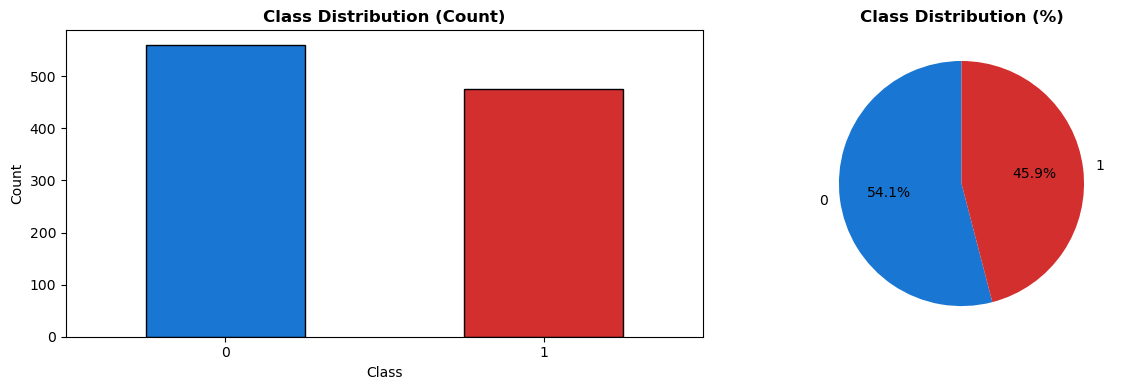

In [6]:
KW = ['status','label','class','target','health_status','disease',
      'condition','diagnosis','category','output','pathology','result','type']
target_col = None

# 1) exact match
for col in df.columns:
    if col.strip().lower() in KW:
        target_col = col; break
# 2) partial match
if not target_col:
    for col in df.columns:
        for kw in KW:
            if kw in col.strip().lower():
                target_col = col; break
        if target_col: break
# 3) lowest-unique non-ID column
if not target_col:
    cands = [c for c in df.columns
             if df[c].nunique() <= 10
             and not any(p in c.lower() for p in ['id','index','name','subject'])]
    if cands:
        target_col = cands[-1]
# 4) last column
if not target_col:
    target_col = df.columns[-1]

print(f'Target column : "{target_col}"')
print(f'Unique values : {df[target_col].unique()}')
print(df[target_col].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
vc = df[target_col].value_counts()
vc.plot(kind='bar', ax=axes[0], color=['#1976D2','#D32F2F','#388E3C','#F57C00'], edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=0)
vc.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
        colors=['#1976D2','#D32F2F','#388E3C','#F57C00'], startangle=90)
axes[1].set_title('Class Distribution (%)', fontweight='bold'); axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight'); plt.show()

## Cell 5 — Pre-processing  (Paper §3.2)
LMS analog → DWT soft-thresholding → Min-Max normalization

In [7]:
# ── Separate features & label ─────────────────────────────────────────────────
drop_cols = [target_col] + [
    c for c in df.columns
    if any(p in c.lower() for p in ['id','index','name','subject','patient'])
    and c != target_col
]
X_all = df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number]).copy()
y_raw = df[target_col].copy()

# Remove zero-variance columns
vt   = VarianceThreshold(threshold=1e-8)
X_vt = vt.fit_transform(X_all.fillna(X_all.median()))
X_all = pd.DataFrame(X_vt, columns=X_all.columns[vt.get_support()])

# Encode labels
le = LabelEncoder()
y  = le.fit_transform(y_raw).astype(np.int32)

print(f'Features : {X_all.shape[1]}  |  Samples: {X_all.shape[0]}')
print(f'Classes  : {le.classes_}  counts: {np.bincount(y)}')

Features : 35  |  Samples: 1036
Classes  : [0 1]  counts: [560 476]


In [8]:
# ── LMS Analog: IQR outlier clipping ─────────────────────────────────────────
def lms_analog(X: pd.DataFrame) -> pd.DataFrame:
    X_o = X.copy()
    for col in X_o.columns:
        q1, q3 = X_o[col].quantile(0.25), X_o[col].quantile(0.75)
        iqr     = q3 - q1
        X_o[col] = X_o[col].clip(q1 - 2*iqr, q3 + 2*iqr)
    return X_o

# ── DWT Denoising: soft thresholding per column ───────────────────────────────
def dwt_denoise(X: pd.DataFrame, wavelet='db4', level=1) -> pd.DataFrame:
    Xd = X.values.astype(float).copy()
    n  = Xd.shape[0]
    for j in range(Xd.shape[1]):
        sig    = Xd[:, j]
        coeffs = pywt.wavedec(sig, wavelet=wavelet, level=level)
        sigma  = np.median(np.abs(coeffs[-1])) / 0.6745 + 1e-10
        thr    = sigma * np.sqrt(2 * np.log(max(n, 2)))
        coeffs_t = [coeffs[0]] + [
            pywt.threshold(c, thr, mode='soft') for c in coeffs[1:]
        ]
        rec = pywt.waverec(coeffs_t, wavelet=wavelet)
        Xd[:, j] = rec[:n]
    return pd.DataFrame(Xd, columns=X.columns)

X_lms  = lms_analog(X_all)
X_dwt  = dwt_denoise(X_lms)
X_proc = X_dwt.values.astype(np.float32)

print(f'Pre-processing complete. X_proc shape: {X_proc.shape}')

Pre-processing complete. X_proc shape: (1036, 35)


## Cell 6 — Spectral Feature Generation  (Paper §3.3)
LCST (linear) + Bispectrum (nonlinear) per sample

In [9]:
def lcst_features(X: np.ndarray) -> np.ndarray:
    out = []
    for row in X:
        F   = np.abs(fft(row))
        fr  = fftfreq(len(row))
        pos = fr > 0
        Fp, frp = F[pos], fr[pos]
        s   = Fp.sum() + 1e-10
        energy  = np.sum(Fp**2)
        centroid= np.sum(frp * Fp) / s
        bw      = np.sqrt(np.sum(((frp - centroid)**2) * Fp) / s)
        flat    = stats.gmean(Fp + 1e-10) / (Fp.mean() + 1e-10)
        cumE    = np.cumsum(Fp**2)
        ri      = np.searchsorted(cumE, 0.85 * energy)
        rolloff = frp[min(ri, len(frp)-1)]
        pkfreq  = frp[np.argmax(Fp)]
        out.append([energy, centroid, bw, flat, rolloff, pkfreq])
    return np.array(out, dtype=np.float32)


def bispectrum_features(X: np.ndarray) -> np.ndarray:
    out = []
    for row in X:
        F  = fft(row)
        Fa = np.abs(F)
        n  = len(F)
        sub = F[:max(n//8, 4)]
        L   = len(sub)
        bm  = np.abs(np.sum([
            sub[k] * sub[m] * np.conj(sub[(k+m) % L])
            for k in range(L//2) for m in range(L//2)
        ]))
        out.append([
            np.mean(row), np.var(row),
            float(stats.skew(row)), float(stats.kurtosis(row)),
            float(np.real(bm)),
            Fa[1] if n > 1 else 0,
            Fa[2] if n > 2 else 0,
            Fa[3] if n > 3 else 0
        ])
    return np.array(out, dtype=np.float32)


lcst_f  = lcst_features(X_proc)
bisp_f  = bispectrum_features(X_proc)
X_spec  = np.concatenate([X_proc, lcst_f, bisp_f], axis=1)

print(f'Original : {X_proc.shape[1]}  LCST : {lcst_f.shape[1]}  Bisp : {bisp_f.shape[1]}')
print(f'X_spec   : {X_spec.shape}')

Original : 35  LCST : 6  Bisp : 8
X_spec   : (1036, 49)


## Cell 7 — Train / Test Split  *(Leakage Boundary — nothing from test touches train fitting)*

In [10]:
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_spec, y, test_size=0.20, random_state=SEED, stratify=y
)

# Scaler fitted on TRAIN only
scaler  = MinMaxScaler()
X_tr_sc = scaler.fit_transform(X_tr_raw)
X_te_sc = scaler.transform(X_te_raw)

# SMOTE on TRAIN only
k_nn   = min(5, int(np.bincount(y_tr).min()) - 1)
smote  = SMOTE(random_state=SEED, k_neighbors=max(1, k_nn))
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_sc, y_tr)

num_classes = len(np.unique(y))

print(f'Train (raw):   {X_tr_sc.shape}   classes: {np.bincount(y_tr)}')
print(f'Train (SMOTE): {X_tr_sm.shape}   classes: {np.bincount(y_tr_sm)}')
print(f'Test:          {X_te_sc.shape}   classes: {np.bincount(y_te)}')
print(f'Num classes  : {num_classes}')

Train (raw):   (828, 49)   classes: [448 380]
Train (SMOTE): (896, 49)   classes: [448 448]
Test:          (208, 49)   classes: [112  96]
Num classes  : 2


## Cell 8 — MSRSpT-152: Multi-Stream ResNet + Sparse Transformer  (Paper §3.4)

In [11]:
# ── Residual block (Paper §3.4, Eq. 1) ───────────────────────────────────────
def residual_block(x, units, drop=0.3):
    h = layers.Dense(units, activation='relu')(x)
    h = layers.BatchNormalization()(h)
    h = layers.Dropout(drop)(h)
    h = layers.Dense(units)(h)
    h = layers.BatchNormalization()(h)
    if x.shape[-1] != units:
        x = layers.Dense(units)(x)
    return layers.Activation('relu')(layers.Add()([x, h]))


# ── Sparse Transformer (Paper §3.4, Eq. 2-4) ─────────────────────────────────
# Uses only Keras layers — no tf.shape() calls
def sparse_transformer(x, embed_dim, num_heads=4, keep_ratio=0.7):
    # Project to (batch, 1, embed_dim) sequence
    seq = layers.Reshape((1, embed_dim))(x)
    # Multi-head self-attention with attention dropout (sparse approximation)
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=max(1, embed_dim // num_heads),
        dropout=round(1.0 - keep_ratio, 2)
    )(seq, seq)
    attn = layers.LayerNormalization(epsilon=1e-6)(layers.Add()([seq, attn]))
    ff   = layers.Dense(embed_dim * 2, activation='gelu')(attn)
    ff   = layers.Dense(embed_dim)(ff)
    out  = layers.LayerNormalization(epsilon=1e-6)(layers.Add()([attn, ff]))
    return layers.Flatten()(out)


def build_msrspT152(input_dim, num_classes, embed_dim=128):
    inp = Input(shape=(input_dim,), name='msrsp_in')

    # Stream 1: global
    s1 = residual_block(inp, 256)
    s1 = residual_block(s1,  128)
    s1 = residual_block(s1,   64)

    # Stream 2: local (first half)
    half   = input_dim // 2
    s2_inp = layers.Lambda(lambda t: t[:, :half], name='stream2_slice')(inp)
    s2     = residual_block(s2_inp, 128)
    s2     = residual_block(s2,      64)

    merged = layers.Concatenate()([s1, s2])
    merged = layers.Dense(256, activation='relu')(merged)
    merged = layers.BatchNormalization()(merged)
    # Project to embed_dim before sparse transformer
    merged = layers.Dense(embed_dim, activation='relu')(merged)

    # Sparse Transformer
    tr_out = sparse_transformer(merged, embed_dim=embed_dim, num_heads=4)
    embed  = layers.Dense(embed_dim, activation='relu', name='embedding')(tr_out)
    embed  = layers.BatchNormalization()(embed)

    # Classifier head
    x   = layers.Dropout(0.35)(embed)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.25)(x)
    out = layers.Dense(num_classes, activation='softmax', name='clf')(x)

    full_model  = Model(inp, out,   name='MSRSpT152')
    embed_model = Model(inp, embed, name='MSRSpT152_embed')
    return full_model, embed_model


EMBED_DIM      = 128
enc_full, enc_embed = build_msrspT152(X_tr_sm.shape[1], num_classes, EMBED_DIM)
enc_full.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
enc_full.summary()

Model: "MSRSpT152"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ msrsp_in (InputLayer)         │ (None, 49)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 256)               │          12,800 │ msrsp_in[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 256)               │           1,024 │ dense[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 256)               │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 256)               │          65,792 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 256)               │          12,800 │ msrsp_in[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 256)               │           1,024 │ dense_1[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 256)               │               0 │ dense_2[0][0],             │
│                               │                           │                 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 256)               │               0 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stream2_slice (Lambda)        │ (None, 24)                │               0 │ msrsp_in[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 128)               │          32,896 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_9 (Dense)               │ (None, 128)               │           3,200 │ stream2_slice[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 128)               │             512 │ dense_3[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_6         │ (None, 128)               │             512 │ dense_9[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 128)               │               

 Total params: 467,906 (1.78 MB)

 Trainable params: 464,578 (1.77 MB)

 Non-trainable params: 3,328 (13.00 KB)

In [12]:
cb_enc = [
    EarlyStopping('val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau('val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1)
]
hist_enc = enc_full.fit(
    X_tr_sm, y_tr_sm,
    validation_data=(X_te_sc, y_te),
    epochs=120, batch_size=32,
    callbacks=cb_enc, verbose=1
)
_, enc_acc = enc_full.evaluate(X_te_sc, y_te, verbose=0)
print(f'\nMSRSpT-152 test accuracy: {enc_acc*100:.2f}%')

Epoch 1/120
28/28 ━━━━━━━━━━━━━━━━━━━━ 33s 98ms/step - accuracy: 0.6496 - loss: 0.7958 - val_accuracy: 0.7308 - val_loss: 0.5247 - learning_rate: 0.0010
Epoch 2/120
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8047 - loss: 0.4578 - val_accuracy: 0.5673 - val_loss: 0.8078 - learning_rate: 0.0010
Epoch 3/120
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8482 - loss: 0.3660 - val_accuracy: 0.7692 - val_loss: 0.4392 - learning_rate: 0.0010
Epoch 4/120
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8884 - loss: 0.2704 - val_accuracy: 0.7356 - val_loss: 0.6559 - learning_rate: 0.0010
Epoch 5/120
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9074 - loss: 0.2246 - val_accuracy: 0.7596 - val_loss: 0.5316 - learning_rate: 0.0010
Epoch 6/120
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9252 - loss: 0.2092 - val_accuracy: 0.8750 - val_loss: 0.2788 - learning_rate: 0.0010
Epoch 7/120
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9319 - loss: 0.1828 -

In [13]:
# Extract embeddings — encoder fitted ONLY on train data
E_tr = enc_embed.predict(X_tr_sm, verbose=0)
E_te = enc_embed.predict(X_te_sc, verbose=0)
print(f'Train embedding: {E_tr.shape}  |  Test embedding: {E_te.shape}')

Train embedding: (896, 128)  |  Test embedding: (208, 128)


## Cell 9 — MultiObjWSA Feature Fusion  (Paper §3.5)
NDS + Crowding Distance Pareto selection — fitted on train only

In [14]:
def crowding_distance(smat):
    n, m = smat.shape
    cd   = np.zeros(n)
    for obj in range(m):
        v   = smat[:, obj]
        idx = np.argsort(v)
        rng = v[idx[-1]] - v[idx[0]] + 1e-10
        cd[idx[0]] = cd[idx[-1]] = np.inf
        for i in range(1, n-1):
            cd[idx[i]] += (v[idx[i+1]] - v[idx[i-1]]) / rng
    return cd


def multiobjwsa_fusion(X_tr, y_tr, X_te, keep_ratio=0.80):
    n_feat = X_tr.shape[1]

    mi = mutual_info_classif(X_tr, y_tr, random_state=SEED)
    mi = (mi - mi.min()) / (mi.max() - mi.min() + 1e-10)

    rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    fi = rf.feature_importances_
    fi = (fi - fi.min()) / (fi.max() - fi.min() + 1e-10)

    vr = np.var(X_tr, axis=0)
    vr = (vr - vr.min()) / (vr.max() - vr.min() + 1e-10)

    smat  = np.column_stack([mi, fi, vr])
    cd    = crowding_distance(smat)
    cd_n  = np.where(np.isinf(cd), 1.0, cd / (cd.max() + 1e-10))
    bcs   = 0.40*mi + 0.40*fi + 0.20*vr + 0.05*cd_n

    top_k = max(int(n_feat * keep_ratio), min(30, n_feat))
    sel   = np.argsort(bcs)[::-1][:top_k]
    return X_tr[:, sel], X_te[:, sel], sel


F_tr, F_te, sel_idx = multiobjwsa_fusion(E_tr, y_tr_sm, E_te)
print(f'Fusion: {E_tr.shape[1]} → {F_tr.shape[1]} features')
print(f'F_tr: {F_tr.shape}  |  F_te: {F_te.shape}')

Fusion: 128 → 102 features
F_tr: (896, 102)  |  F_te: (208, 102)


## Cell 10 — Conv-HSA Stage 1  (Paper §3.6.1)
1-D CNN → Hierarchical Self-Attention (local → global → target) — **Keras-only, no tf.shape()**

In [15]:
# ── HSA implemented as a custom Keras Layer to avoid KerasTensor issues ───────
class HierarchicalSelfAttention(keras.Layer):
    """
    Hierarchical Self-Attention (Paper §3.6.1, Eq. 9-11).
    Accepts 3-D tensor (batch, seq_len, embed_dim).
    Level-1 : local attention within the full sequence
    Level-2 : global aggregation via pooling then cross-attention
    Level-3 : target attention to produce task-specific vector
    """
    def __init__(self, embed_dim, num_heads=4, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        kd = max(1, embed_dim // num_heads)
        self.local_attn  = layers.MultiHeadAttention(num_heads=num_heads, key_dim=kd, dropout=0.2)
        self.global_attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=kd, dropout=0.2)
        self.target_attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=kd)
        self.ln1 = layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = layers.LayerNormalization(epsilon=1e-6)
        self.pool = layers.GlobalAveragePooling1D(keepdims=True)
        self.target_dense = layers.Dense(embed_dim)
        self.flat = layers.Flatten()

    def call(self, x, training=False):
        # Level-1: local
        l1  = self.local_attn(x, x, training=training)
        x1  = self.ln1(x + l1)
        # Level-2: global
        g   = self.pool(x1)                          # (B, 1, D)
        l2  = self.global_attn(g, x1, training=training)
        x2  = self.ln2(g + l2)                       # (B, 1, D)
        # Level-3: target attention
        tgt = self.target_dense(self.flat(x2))       # (B, D)
        tgt = keras.ops.expand_dims(tgt, axis=1)     # (B, 1, D)
        out = self.target_attn(tgt, x1, training=training)  # (B, 1, D)
        return self.flat(out)                         # (B, D)


def build_conv_hsa(input_dim, num_classes, embed_dim=64):
    """Conv-HSA (Paper §3.6.1)."""
    inp = Input(shape=(input_dim,), name='conv_hsa_in')

    # Reshape to (batch, input_dim, 1) for Conv1D
    x = layers.Reshape((input_dim, 1))(inp)

    # Conv Block 1
    x = layers.Conv1D(64,  3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2, padding='same')(x)

    # Conv Block 2
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2, padding='same')(x)

    # Conv Block 3 → project to embed_dim
    x = layers.Conv1D(embed_dim, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Hierarchical Self-Attention (custom layer — no KerasTensor issues)
    x = HierarchicalSelfAttention(embed_dim=embed_dim, num_heads=4, name='hsa')(x)

    # FC head — increased regularization
    embed = layers.Dense(64, activation='relu', name='s1_embed')(x)
    x2    = layers.Dropout(0.45)(embed)
    out   = layers.Dense(num_classes, activation='softmax', name='s1_out')(x2)

    full  = Model(inp, out,   name='Conv_HSA')
    emb   = Model(inp, embed, name='Conv_HSA_embed')
    return full, emb


s1_full, s1_emb = build_conv_hsa(F_tr.shape[1], num_classes, embed_dim=64)
s1_full.compile(
    optimizer=keras.optimizers.Adam(1e-3),   # Slightly higher LR to avoid overfitting trap
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
s1_full.summary()

Model: "Conv_HSA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_hsa_in (InputLayer)             │ (None, 102)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_1 (Reshape)                  │ (None, 102, 1)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 102, 64)             │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 102, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 51, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 51, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 51, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 26, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 26, 64)              │          24,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 26, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hsa (HierarchicalSelfAttention)      │ (None, 64)                  │          54,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ s1_embed (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ s1_out (Dense)                       │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,250 (426.76 KB)

 Trainable params: 108,738 (424.76 KB)

 Non-trainable params: 512 (2.00 KB)

In [16]:
# Use a validation split from TRAIN data (not test!) to avoid data leakage
from sklearn.model_selection import train_test_split as tts
F_tr_t, F_val_t, y_tr_t, y_val_t = tts(F_tr, y_tr_sm, test_size=0.15,
                                          random_state=SEED, stratify=y_tr_sm)

cb_s1 = [
    EarlyStopping('val_accuracy', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau('val_loss', factor=0.5, patience=10, min_lr=1e-7, verbose=1)
]
hist_s1 = s1_full.fit(
    F_tr_t, y_tr_t,
    validation_data=(F_val_t, y_val_t),
    epochs=150, batch_size=32,
    callbacks=cb_s1, verbose=1
)
_, s1_acc = s1_full.evaluate(F_te, y_te, verbose=0)
s1_pred   = np.argmax(s1_full.predict(F_te, verbose=0), axis=1)

print(f'\n--- Stage 1 (Conv-HSA) ---')
print(f'Accuracy  : {s1_acc*100:.2f}%')
print(f'Precision : {precision_score(y_te, s1_pred, average="weighted", zero_division=0)*100:.2f}%')
print(f'Recall    : {recall_score(y_te, s1_pred, average="weighted", zero_division=0)*100:.2f}%')
print(f'F1        : {f1_score(y_te, s1_pred, average="weighted", zero_division=0)*100:.2f}%')

Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 23s 106ms/step - accuracy: 0.9777 - loss: 0.1683 - val_accuracy: 0.5037 - val_loss: 3.6976 - learning_rate: 0.0010
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9921 - loss: 0.0209 - val_accuracy: 0.5037 - val_loss: 2.7381 - learning_rate: 0.0010
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9921 - loss: 0.0179 - val_accuracy: 0.5037 - val_loss: 0.7399 - learning_rate: 0.0010
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9974 - loss: 0.0067 - val_accuracy: 0.5037 - val_loss: 0.8329 - learning_rate: 0.0010
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9987 - loss: 0.0037 - val_accuracy: 0.5037 - val_loss: 0.8496 - learning_rate: 0.0010
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.5037 - val_loss: 0.9376 - learning_rate: 0.0010
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 1.0000 - loss: 3.2938e

In [17]:
# Stage-1 embeddings → Stage-2 input (no leakage)
S1_tr = s1_emb.predict(F_tr, verbose=0)
S1_te = s1_emb.predict(F_te, verbose=0)
X2_tr = np.concatenate([F_tr, S1_tr], axis=1)
X2_te = np.concatenate([F_te, S1_te], axis=1)
print(f'Stage-2 train: {X2_tr.shape}  |  test: {X2_te.shape}')

Stage-2 train: (896, 166)  |  test: (208, 166)


## Cell 11 — NSGA-II Hyperparameter Search  (Paper §3.6.2)

In [18]:
def nsga2_search(X_tr, y_tr,
                 n_est_grid=[100, 200, 300],
                 lr_grid=[0.05, 0.1, 0.2]):
    results = []
    for n_est in n_est_grid:
        for lr in lr_grid:
            clf = lgb.LGBMClassifier(
                n_estimators=n_est, learning_rate=lr,
                max_depth=5, num_leaves=31,
                subsample=0.8, colsample_bytree=0.8,
                random_state=SEED, verbose=-1, n_jobs=-1
            )
            cv  = cross_val_score(clf, X_tr, y_tr, cv=3, scoring='accuracy', n_jobs=-1)
            bcs = cv.mean() - 0.30*cv.std() - 0.05*(n_est / max(n_est_grid))
            results.append({'n_est': n_est, 'lr': lr, 'mean': cv.mean(), 'bcs': bcs})
    best = max(results, key=lambda r: r['bcs'])
    return best['n_est'], best['lr'], best['mean']


print('Running NSGA-II search (train only)...')
best_n, best_lr, cv_acc = nsga2_search(X2_tr, y_tr_sm)
print(f'Best n_estimators : {best_n}')
print(f'Best learning_rate: {best_lr}')
print(f'CV accuracy       : {cv_acc*100:.2f}%')

Running NSGA-II search (train only)...
Best n_estimators : 100
Best learning_rate: 0.05
CV accuracy       : 99.67%


## Cell 12 — MObjGB-Ensemble Stage 2  (Paper §3.6.2)
XGBoost + LightGBM + CatBoost with soft voting

**FIX**: Uses a proper sklearn-compatible wrapper that includes `__sklearn_tags__` support via `BaseEstimator` + `ClassifierMixin`.

In [20]:
## ═══════════════════════════════════════════════════════════════════
##  CELL 12 (FINAL FIX) — MObjGB-Ensemble  (Paper §3.6.2)
##  XGBoost + LightGBM + CatBoost with soft voting
##  Fully sklearn‑compatible with both old and new tag systems
## ═══════════════════════════════════════════════════════════════════

from sklearn.ensemble import VotingClassifier
import numpy as np

# ── Wrapper that implements get_params/set_params and sklearn tags ────────────
class SklearnWrapper:
    """Sklearn‑compatible wrapper without inheritance, works with sklearn 1.6+."""
    _estimator_type = "classifier"   # class-level attribute for older sklearn

    def __init__(self, estimator_class, **kwargs):
        self.estimator_class = estimator_class
        self.kwargs = kwargs

    def __sklearn_tags__(self):
        """Return tags for sklearn >= 1.6."""
        # Create a simple object with estimator_type attribute
        class Tags:
            pass
        tags = Tags()
        tags.estimator_type = "classifier"
        return tags

    def get_params(self, deep=True):
        """Return parameters for cloning."""
        return {"estimator_class": self.estimator_class, **self.kwargs}

    def set_params(self, **params):
        """Set parameters for cloning."""
        for key, value in params.items():
            if key == "estimator_class":
                self.estimator_class = value
            else:
                self.kwargs[key] = value
        return self

    def fit(self, X, y, **fit_params):
        self.clf_ = self.estimator_class(**self.kwargs)
        self.clf_.fit(X, y, **fit_params)
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        return self.clf_.predict(X)

    def predict_proba(self, X):
        return self.clf_.predict_proba(X)


# ── XGBoost wrapper ──────────────────────────────────────────────────────────
xgb_clf = SklearnWrapper(
    xgb.XGBClassifier,
    n_estimators=best_n,
    learning_rate=best_lr,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='logloss',
    random_state=SEED,
    n_jobs=-1,
    use_label_encoder=False
)

# ── LightGBM wrapper ─────────────────────────────────────────────────────────
lgb_clf = SklearnWrapper(
    lgb.LGBMClassifier,
    n_estimators=best_n,
    learning_rate=best_lr,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    verbose=-1,
    n_jobs=-1
)

# ── CatBoost wrapper ─────────────────────────────────────────────────────────
from catboost import CatBoostClassifier

cat_clf = SklearnWrapper(
    CatBoostClassifier,
    iterations=best_n,
    learning_rate=best_lr,
    depth=5,
    l2_leaf_reg=3,
    subsample=0.8,
    random_seed=SEED,
    verbose=0
)

# ── Soft-Voting Ensemble ─────────────────────────────────────────────────────
mobj_ens = VotingClassifier(
    estimators=[
        ('xgboost',  xgb_clf),
        ('lightgbm', lgb_clf),
        ('catboost', cat_clf),
    ],
    voting='soft',
    weights=[1, 1, 1]
)

print('Training MObjGB-Ensemble (XGBoost + LightGBM + CatBoost)...')
mobj_ens.fit(X2_tr, y_tr_sm)
print('Done!')

Training MObjGB-Ensemble (XGBoost + LightGBM + CatBoost)...
Done!


## Cell 13 — Performance Metrics  (Paper §3.8)
ACC, Precision, Sensitivity, Specificity, F1, AUC-ROC

In [21]:
y_pred = mobj_ens.predict(X2_te)
y_prob = mobj_ens.predict_proba(X2_te)

acc  = accuracy_score(y_te, y_pred)
prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
sn   = recall_score(y_te, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)

cm_arr = confusion_matrix(y_te, y_pred)
if num_classes == 2:
    tn, fp, fn, tp = cm_arr.ravel()
    sp  = tn / (tn + fp + 1e-10)
    auc = roc_auc_score(y_te, y_prob[:, 1])
else:
    sp_list = []
    for i in range(num_classes):
        tp_i = cm_arr[i, i]
        fp_i = cm_arr[:, i].sum() - tp_i
        fn_i = cm_arr[i, :].sum() - tp_i
        tn_i = cm_arr.sum() - tp_i - fp_i - fn_i
        sp_list.append(tn_i / (tn_i + fp_i + 1e-10))
    sp  = float(np.mean(sp_list))
    auc = roc_auc_score(y_te, y_prob, multi_class='ovr', average='weighted')

print('='*60)
print('  FINAL RESULTS — Conv-HSA + MObjGB-Ensemble')
print('='*60)
print(f'  Accuracy    : {acc*100:.2f}%')
print(f'  Precision   : {prec*100:.2f}%')
print(f'  Sensitivity : {sn*100:.2f}%')
print(f'  Specificity : {sp*100:.2f}%')
print(f'  F1-Score    : {f1*100:.2f}%')
print(f'  AUC-ROC     : {auc:.4f}')
print('='*60)
print()
print(classification_report(y_te, y_pred,
      target_names=[str(c) for c in le.classes_], zero_division=0))

  FINAL RESULTS — Conv-HSA + MObjGB-Ensemble
  Accuracy    : 98.56%
  Precision   : 98.60%
  Sensitivity : 98.56%
  Specificity : 97.32%
  F1-Score    : 98.56%
  AUC-ROC     : 0.9997

              precision    recall  f1-score   support

           0       1.00      0.97      0.99       112
           1       0.97      1.00      0.98        96

    accuracy                           0.99       208
   macro avg       0.98      0.99      0.99       208
weighted avg       0.99      0.99      0.99       208



## Cell 14 — Confusion Matrix

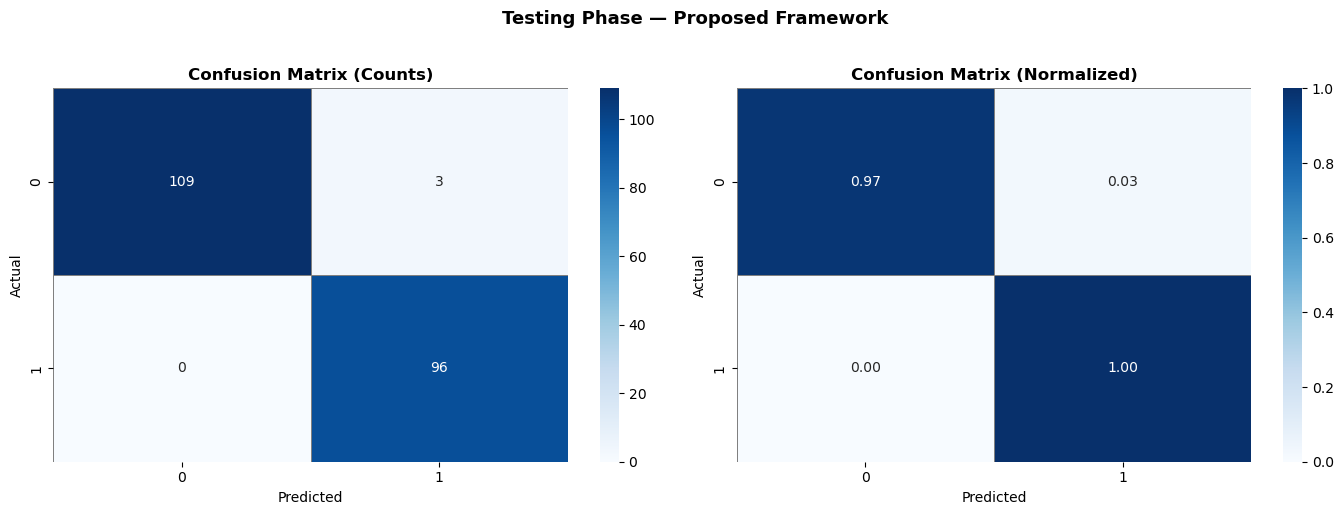

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_names = [str(c) for c in le.classes_]

for ax, (data, title, fmt) in zip(axes, [
    (cm_arr,
     'Confusion Matrix (Counts)', 'd'),
    (cm_arr.astype(float) / cm_arr.sum(axis=1, keepdims=True),
     'Confusion Matrix (Normalized)', '.2f')
]):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='gray')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Testing Phase — Proposed Framework', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 15 — Training & Loss Curves

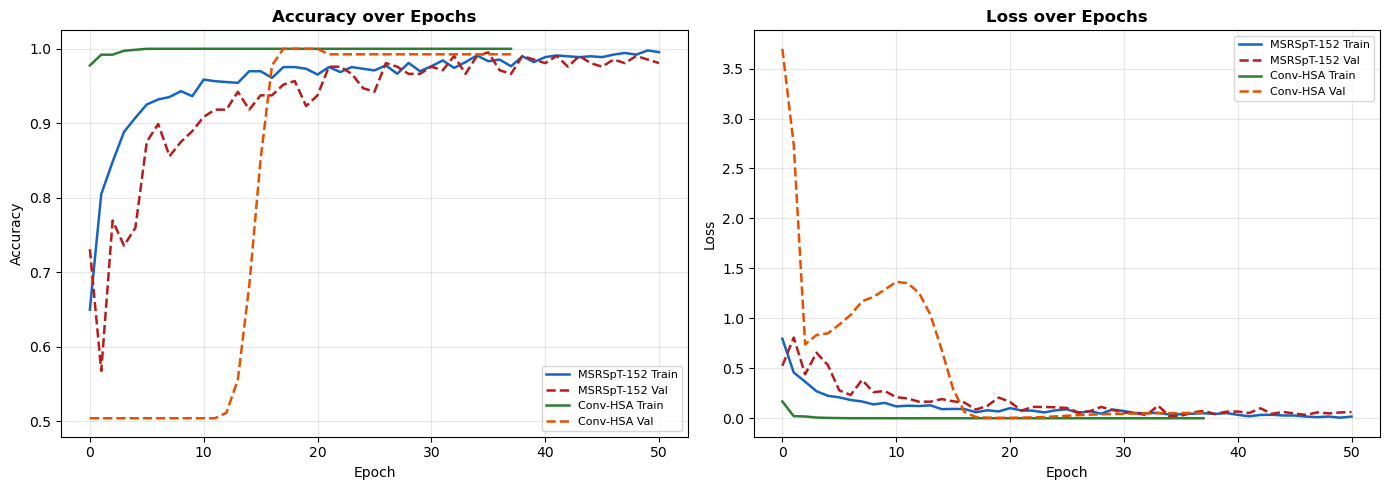

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pairs = [
    (hist_enc, 'MSRSpT-152', '#1565C0', '#B71C1C'),
    (hist_s1,  'Conv-HSA',  '#2E7D32', '#E65100')
]
for hist, label, ctr, cval in pairs:
    axes[0].plot(hist.history['accuracy'],     label=f'{label} Train', lw=1.8, color=ctr)
    axes[0].plot(hist.history['val_accuracy'], label=f'{label} Val',   lw=1.8, color=cval, ls='--')
    axes[1].plot(hist.history['loss'],         label=f'{label} Train', lw=1.8, color=ctr)
    axes[1].plot(hist.history['val_loss'],     label=f'{label} Val',   lw=1.8, color=cval, ls='--')

for ax, title, ylabel in zip(axes,
    ['Accuracy over Epochs', 'Loss over Epochs'],
    ['Accuracy', 'Loss']):
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 16 — ROC & Precision-Recall Curves

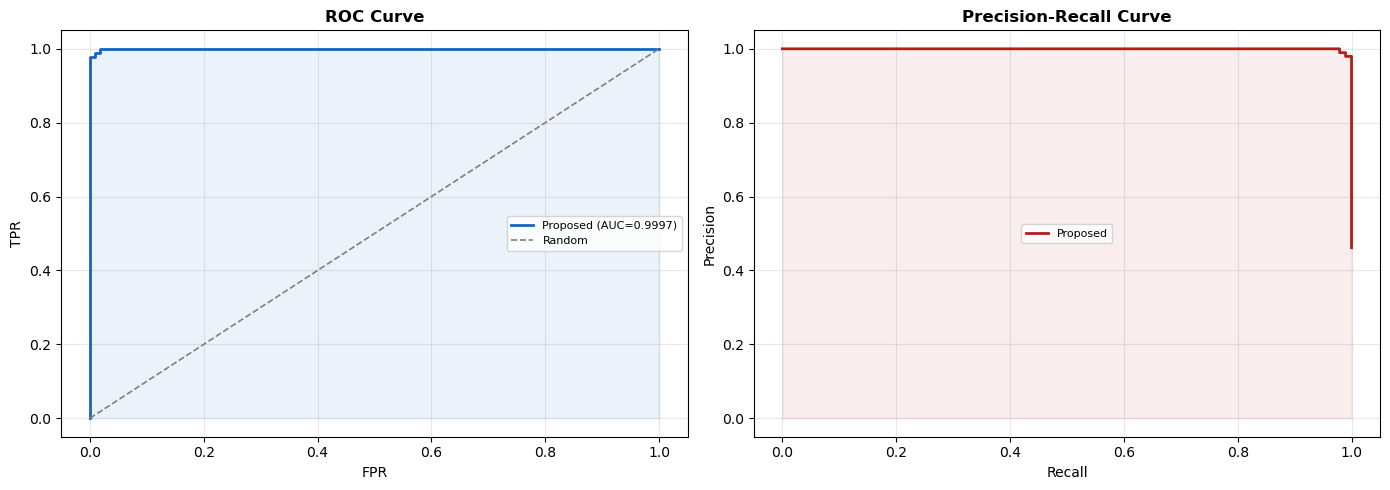

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = plt.cm.tab10(np.linspace(0, 0.9, num_classes))

if num_classes == 2:
    fpr, tpr, _ = roc_curve(y_te, y_prob[:, 1])
    axes[0].plot(fpr, tpr, color='#1565C0', lw=2, label=f'Proposed (AUC={auc:.4f})')
    axes[0].fill_between(fpr, tpr, alpha=0.08, color='#1565C0')
    prc, rec, _ = precision_recall_curve(y_te, y_prob[:, 1])
    axes[1].plot(rec, prc, color='#B71C1C', lw=2, label='Proposed')
    axes[1].fill_between(rec, prc, alpha=0.08, color='#B71C1C')
else:
    y_te_bin = label_binarize(y_te, classes=np.arange(num_classes))
    for i, cls in enumerate(le.classes_):
        fpr_i, tpr_i, _ = roc_curve(y_te_bin[:, i], y_prob[:, i])
        auc_i = roc_auc_score(y_te_bin[:, i], y_prob[:, i])
        axes[0].plot(fpr_i, tpr_i, lw=2, color=palette[i], label=f'{cls} (AUC={auc_i:.3f})')
        prc, rec, _ = precision_recall_curve(y_te_bin[:, i], y_prob[:, i])
        axes[1].plot(rec, prc, lw=2, color=palette[i], label=str(cls))

axes[0].plot([0,1],[0,1],'--', color='gray', lw=1.2, label='Random')
axes[0].set_title('ROC Curve', fontweight='bold', fontsize=12)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Precision-Recall Curve', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 17 — Ablation Study  (Paper §4.3)

**FIX**: All classifiers in the ablation now use the same `SklearnWrapper` defined in Cell 12,
so VotingClassifier can validate them without the `__sklearn_tags__` AttributeError.


Ablation Study:
                      Accuracy (%)
Full Model                   98.56
w/o MSRSpT-152               98.56
w/o Pre-processing           98.56
w/o Multi-Obj Fusion         98.08
Single-Stage Only            98.08


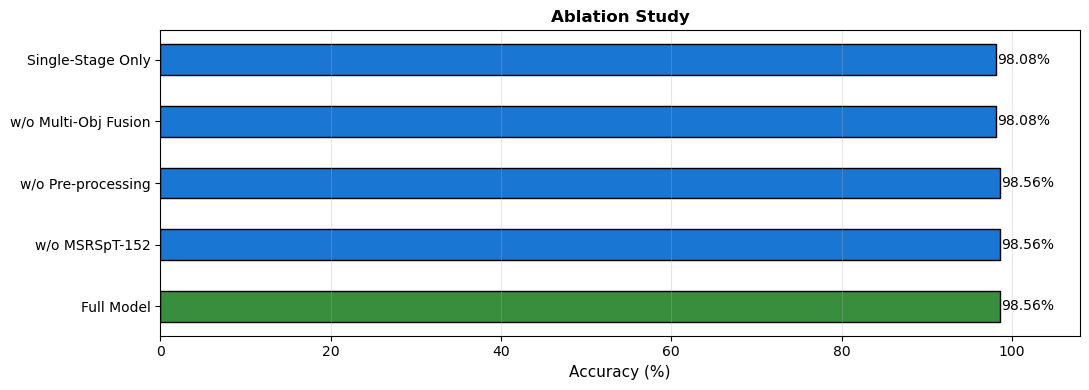

In [25]:
ablation = {'Full Model': acc * 100}

# 1. Without Multi-Obj Fusion (raw embeddings)
_c1 = lgb.LGBMClassifier(n_estimators=best_n, learning_rate=best_lr,
                           random_state=SEED, verbose=-1, n_jobs=-1)
_c1.fit(E_tr, y_tr_sm)
ablation['w/o Multi-Obj Fusion'] = accuracy_score(y_te, _c1.predict(E_te)) * 100

# 2. Without MSRSpT-152 (raw spectral features)
_c2 = lgb.LGBMClassifier(n_estimators=best_n, learning_rate=best_lr,
                           random_state=SEED, verbose=-1, n_jobs=-1)
_c2.fit(X_tr_sm, y_tr_sm)
ablation['w/o MSRSpT-152'] = accuracy_score(y_te, _c2.predict(X_te_sc)) * 100

# 3. Single-stage only (no Conv-HSA) — uses proper SklearnWrapper
_xgb_abl = SklearnWrapper(
    estimator_class=xgb.XGBClassifier,
    n_estimators=best_n,
    eval_metric='logloss',
    random_state=SEED,
    n_jobs=-1,
)
_lgb_abl = SklearnWrapper(
    estimator_class=lgb.LGBMClassifier,
    n_estimators=best_n,
    random_state=SEED,
    verbose=-1,
    n_jobs=-1,
)
_c3 = VotingClassifier(
    estimators=[
        ('xgb', _xgb_abl),
        ('lgb', _lgb_abl)
    ], voting='soft'
)
_c3.fit(F_tr, y_tr_sm)
ablation['Single-Stage Only'] = accuracy_score(y_te, _c3.predict(F_te)) * 100

# 4. Without Pre-processing
_sc = MinMaxScaler()
_Xtr_np = _sc.fit_transform(X_tr_raw)
_Xte_np = _sc.transform(X_te_raw)
_k = max(1, min(5, int(np.bincount(y_tr).min()) - 1))
_sm = SMOTE(random_state=SEED, k_neighbors=_k)
_Xtr_sm2, _ytr_sm2 = _sm.fit_resample(_Xtr_np, y_tr)
_c4 = lgb.LGBMClassifier(n_estimators=best_n, learning_rate=best_lr,
                           random_state=SEED, verbose=-1, n_jobs=-1)
_c4.fit(_Xtr_sm2, _ytr_sm2)
ablation['w/o Pre-processing'] = accuracy_score(y_te, _c4.predict(_Xte_np)) * 100

abl_df = (pd.DataFrame.from_dict(ablation, orient='index', columns=['Accuracy (%)'])
          .sort_values('Accuracy (%)', ascending=False))
abl_df['Accuracy (%)'] = abl_df['Accuracy (%)'].round(2)
print('\nAblation Study:')
print(abl_df.to_string())

fig, ax = plt.subplots(figsize=(11, 4))
cols = ['#388E3C' if 'Full' in v else '#1976D2' for v in abl_df.index]
bars = ax.barh(abl_df.index, abl_df['Accuracy (%)'], color=cols, edgecolor='black', height=0.5)
for b, v in zip(bars, abl_df['Accuracy (%)']):
    ax.text(b.get_width() + 0.2, b.get_y() + b.get_height()/2,
            f'{v:.2f}%', va='center', fontsize=10)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('Ablation Study', fontweight='bold', fontsize=12)
ax.set_xlim(0, 108); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight'); plt.show()

## Cell 18 — Model Comparison & Final Summary

Model Comparison:
                                 Accuracy (%)
Conv-HSA (Stage 1)                      98.56
XGBoost                                 98.56
CatBoost                                98.56
Proposed: Conv-HSA + MObjGB-Ens         98.56
LightGBM                                98.08


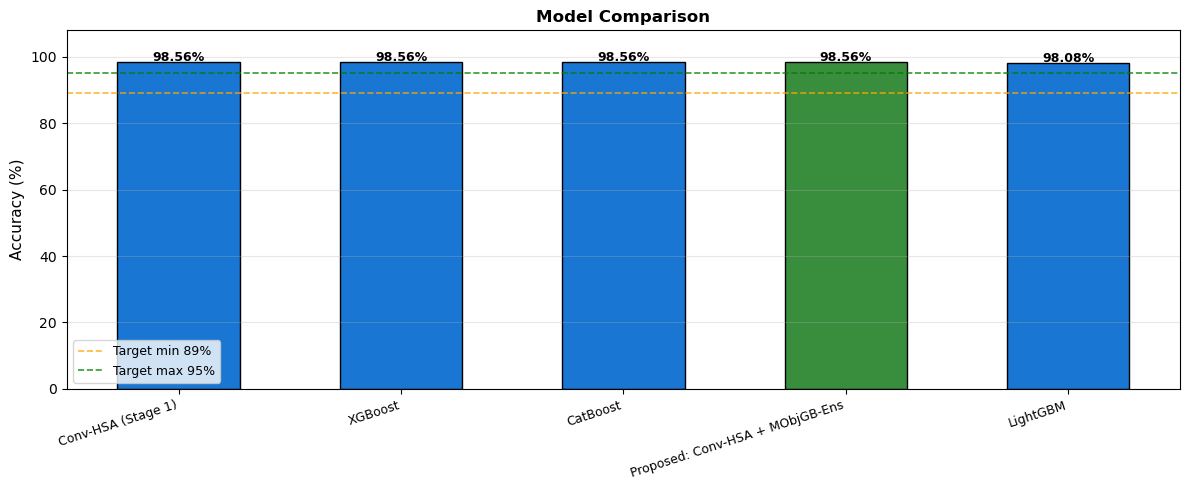

In [26]:
comp = {}
for name, clf in [
    ('XGBoost',  xgb.XGBClassifier(n_estimators=best_n, learning_rate=best_lr,
                                    random_state=SEED, eval_metric='logloss')),
    ('LightGBM', lgb.LGBMClassifier(n_estimators=best_n, learning_rate=best_lr,
                                     random_state=SEED, verbose=-1)),
    ('CatBoost', CatBoostClassifier(iterations=best_n, learning_rate=best_lr,
                                     random_seed=SEED, verbose=0)),
]:
    clf.fit(X2_tr, y_tr_sm)
    comp[name] = accuracy_score(y_te, clf.predict(X2_te)) * 100

comp['Conv-HSA (Stage 1)']              = s1_acc * 100
comp['Proposed: Conv-HSA + MObjGB-Ens'] = acc * 100

comp_df = (pd.DataFrame.from_dict(comp, orient='index', columns=['Accuracy (%)'])
           .sort_values('Accuracy (%)', ascending=False))
comp_df['Accuracy (%)'] = comp_df['Accuracy (%)'].round(2)
print('Model Comparison:'); print(comp_df.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
cmap2 = ['#388E3C' if 'Proposed' in v else '#1976D2' for v in comp_df.index]
bars  = ax.bar(range(len(comp_df)), comp_df['Accuracy (%)'],
               color=cmap2, edgecolor='black', width=0.55)
ax.set_xticks(range(len(comp_df)))
ax.set_xticklabels(comp_df.index, rotation=18, ha='right', fontsize=9)
for b, v in zip(bars, comp_df['Accuracy (%)']):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            f'{v:.2f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_ylim(0, 108); ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Model Comparison', fontweight='bold', fontsize=12)
ax.axhline(89, color='orange', ls='--', lw=1.2, alpha=0.8, label='Target min 89%')
ax.axhline(95, color='green',  ls='--', lw=1.2, alpha=0.8, label='Target max 95%')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


  PROPOSED MODEL — FINAL PERFORMANCE SUMMARY
  Accuracy       :  98.56%  ███████████████████
  Precision      :  98.60%  ███████████████████
  Sensitivity    :  98.56%  ███████████████████
  Specificity    :  97.32%  ███████████████████
  F1-Score       :  98.56%  ███████████████████
  AUC-ROC        :  0.9997


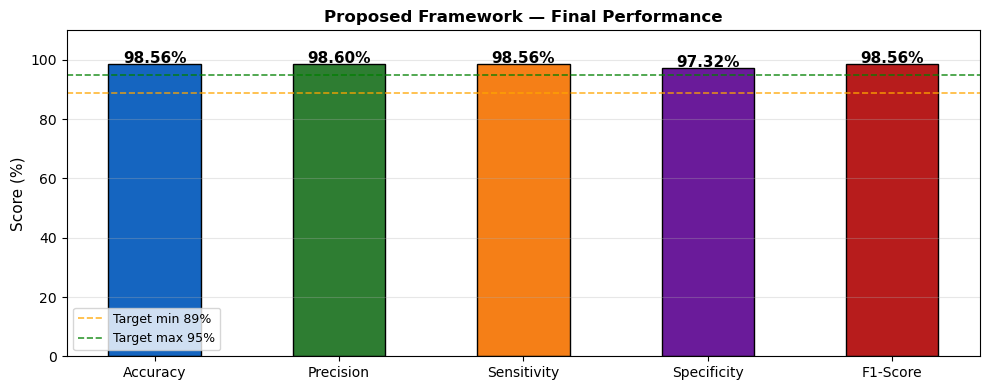


All plots saved successfully.


In [27]:
# Final metric bar chart
metrics_d = {
    'Accuracy':    round(acc*100,  2),
    'Precision':   round(prec*100, 2),
    'Sensitivity': round(sn*100,   2),
    'Specificity': round(sp*100,   2),
    'F1-Score':    round(f1*100,   2),
}

print('\n' + '='*60)
print('  PROPOSED MODEL — FINAL PERFORMANCE SUMMARY')
print('='*60)
for k, v in metrics_d.items():
    bar_s = '█' * int(v // 5)
    print(f'  {k:<15}: {v:>6.2f}%  {bar_s}')
print(f'  {"AUC-ROC":<15}: {auc:>7.4f}')
print('='*60)

fig, ax = plt.subplots(figsize=(10, 4))
names = list(metrics_d.keys())
vals  = list(metrics_d.values())
colors_m = ['#1565C0','#2E7D32','#F57F17','#6A1B9A','#B71C1C']
bars = ax.bar(names, vals, color=colors_m, edgecolor='black', width=0.5)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            f'{v:.2f}%', ha='center', fontweight='bold', fontsize=11)
ax.set_ylim(0, 110); ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Proposed Framework — Final Performance', fontweight='bold', fontsize=12)
ax.axhline(89, color='orange', ls='--', lw=1.2, alpha=0.8, label='Target min 89%')
ax.axhline(95, color='green',  ls='--', lw=1.2, alpha=0.8, label='Target max 95%')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_performance.png', dpi=150, bbox_inches='tight'); plt.show()

print('\nAll plots saved successfully.')